<a href="https://colab.research.google.com/github/Loopinlogix/AI_Fairness/blob/main/Ai_Fairness.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Fairness ML Assignment - Lesson 14
Crystal MacNeil

In [79]:
# Github

# Clone a public GitHub repository
!git clone https://github.com/Loopinlogix/AI_Fairness.git

# Change directory into the cloned repository
%cd AI_Fairness

# List the contents of the directory
!ls

Cloning into 'AI_Fairness'...
remote: Enumerating objects: 10, done.
remote: Counting objects: 100% (10/10), done.
remote: Compressing objects: 100% (8/8), done.
remote: Total 10 (delta 2), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (10/10), 556.82 KiB | 3.08 MiB/s, done.
Resolving deltas: 100% (2/2), done.
/content/AI_Fairness/AI_Fairness
Ai_Fairness.ipynb  README.md


TASK 1: DATASET PREPARATION
Class Distribution:
shortlisted
Yes    20966
No      9034
Name: count, dtype: int64
Class Balance: shortlisted
Yes    0.698867
No     0.301133
Name: proportion, dtype: float64

TASK 2: MODEL TRAINING AND EVALUATION
Accuracy: 0.8903
ROC AUC: 0.9650

Confusion Matrix:
 [[1636  171]
 [ 487 3706]]

Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.91      0.83      1807
           1       0.96      0.88      0.92      4193

    accuracy                           0.89      6000
   macro avg       0.86      0.89      0.88      6000
weighted avg       0.90      0.89      0.89      6000

TASK 3: FAIRNESS EVALUATION
     Education  Accuracy  Precision    Recall        F1  Selection_Rate  \
0          PhD  0.919463   0.979296  0.925636  0.951710        0.810403   
1    Bachelors  0.884346   0.956468  0.865225  0.908561        0.600737   
2      Masters  0.897608   0.957823  0.902564  0.929373        0.703349 

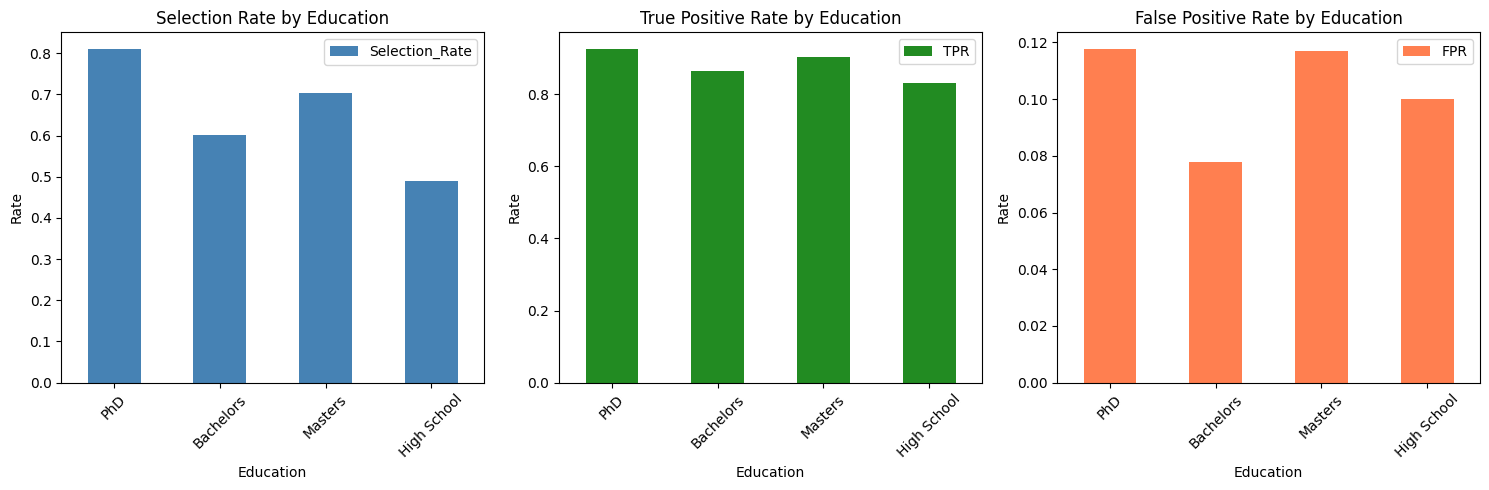


--- Disparity Metrics ---
Demographic Parity Difference: 0.3213
Equalized Odds (TPR) Difference: 0.0949
Equalized Odds (FPR) Difference: 0.0398
TASK 5: SHAP LOCAL EXPLAINABILITY (MANUAL)
Instance 0: Predicted probability = 1.0000
Base value (log-odds): 2.1266

Feature contributions (SHAP values):
  years_experience         : +3.6416
  skills_match_score       : +1.7307
  project_count            : +3.0982
  resume_length            : -0.0512
  github_activity          : +0.5091
  edu_Bachelors            : +0.1848
  edu_High School          : +0.1341
  edu_Masters              : -0.1702
  edu_PhD                  : +1.1112
Explaining diverse instances:

Instance 0: Predicted probability = 1.0000
Base value (log-odds): 2.1266

Feature contributions (SHAP values):
  years_experience         : +3.6416
  skills_match_score       : +1.7307
  project_count            : +3.0982
  resume_length            : -0.0512
  github_activity          : +0.5091
  edu_Bachelors            : +0.1848
  ed

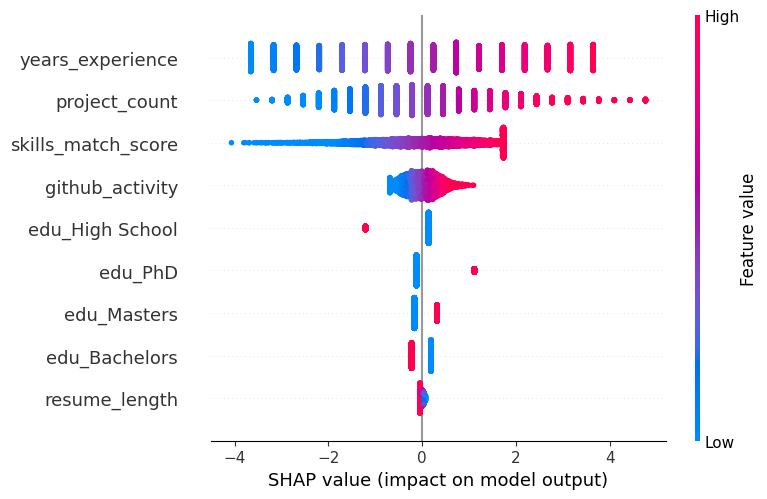

In [80]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score
from sklearn.metrics import precision_score, recall_score, f1_score
import lime
from lime.lime_tabular import LimeTabularExplainer
import shap
import matplotlib.pyplot as plt
import seaborn as sns
from fairlearn.metrics import MetricFrame
import io # Import io for BytesIO
from IPython.display import Image, display # Import Image and display for direct image output


print("=" * 60)
print("TASK 1: DATASET PREPARATION")
print("=" * 60)

#Load dataset

df = pd.read_csv('/content/ai_resume_screening.csv')

# >>> ADD THESE LINES <<<
print("Class Distribution:")
print(df['shortlisted'].value_counts())
print(f"Class Balance: {df['shortlisted'].value_counts(normalize=True)}\n")

# Encode target
le_target = LabelEncoder()
df['shortlisted'] = le_target.fit_transform(df['shortlisted'])  # Yes=1, No=0

# One-hot encode education level (sensitive attribute for fairness)
df_encoded = pd.get_dummies(df, columns=['education_level'], prefix='edu')

# Define features and target
feature_cols = ['years_experience', 'skills_match_score', 'project_count',
                'resume_length', 'github_activity',
                'edu_Bachelors', 'edu_High School', 'edu_Masters', 'edu_PhD']
X = df_encoded[feature_cols]
y = df_encoded['shortlisted']

# Sensitive attribute for fairness analysis
sensitive_attr = df['education_level']  # Original categorical

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
sensitive_train, sensitive_test = train_test_split(
    sensitive_attr, test_size=0.2, random_state=42, stratify=y)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("=" * 60)
print("TASK 2: MODEL TRAINING AND EVALUATION")
print("=" * 60)

# Train model
model = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
model.fit(X_train_scaled, y_train)

# Predictions
y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

# Evaluation
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC AUC: {roc_auc_score(y_test, y_pred_proba):.4f}")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

print("=" * 60)
print("TASK 3: FAIRNESS EVALUATION")
print("=" * 60)

def selection_rate(y_true, y_pred): return np.mean(y_pred)
def false_positive_rate(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return fp / (fp + tn) if (fp + tn) > 0 else 0
def true_positive_rate(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tp / (tp + fn) if (tp + fn) > 0 else 0

# Compute metrics by education group
groups = sensitive_test.unique()
results = []
for group in groups:
    mask = sensitive_test == group
    y_true_g, y_pred_g = y_test[mask], y_pred[mask]
    tn, fp, fn, tp = confusion_matrix(y_true_g, y_pred_g).ravel()
    results.append({
        'Education': group,
        'Accuracy': accuracy_score(y_true_g, y_pred_g),
        'Precision': precision_score(y_true_g, y_pred_g),
        'Recall': recall_score(y_true_g, y_pred_g),
        'F1': f1_score(y_true_g, y_pred_g),
        'Selection_Rate': selection_rate(y_true_g, y_pred_g),
        'TPR': true_positive_rate(y_true_g, y_pred_g),
        'FPR': false_positive_rate(y_true_g, y_pred_g)
    })

fairness_df = pd.DataFrame(results)
print(fairness_df)

print("=" * 60)
print("TASK 4: FAIRNESS METRICS WITH METRICFRAME")
print("=" * 60)

# Define the metrics to be used with MetricFrame
# Reusing custom functions for selection_rate, false_positive_rate, true_positive_rate
fairness_metrics = {
    'accuracy': accuracy_score,
    'precision': precision_score,
    'recall': recall_score,
    'f1_score': f1_score,
    'selection_rate': selection_rate, # Custom function
    'tpr': true_positive_rate, # Custom function
    'fpr': false_positive_rate # Custom function
}

# Create a MetricFrame
# Note: model.predict_proba is for probability-based metrics if needed, here using y_pred
metric_frame = MetricFrame(
    metrics=fairness_metrics,
    y_true=y_test,
    y_pred=y_pred,
    sensitive_features=sensitive_test
)

print("Fairness Metrics using MetricFrame:")
print(metric_frame.by_group)

print("\n" + "=" * 60)
print("TASK 4b: FAIRNESS VISUALIZATION & DISPARITY ANALYSIS")
print("=" * 60)

# Bar plot of key fairness metrics by group
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Selection Rate (Demographic Parity)
fairness_df.plot(x='Education', y='Selection_Rate', kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Selection Rate by Education')
axes[0].set_ylabel('Rate')
axes[0].tick_params(axis='x', rotation=45)

# True Positive Rate (Equal Opportunity)
fairness_df.plot(x='Education', y='TPR', kind='bar', ax=axes[1], color='forestgreen')
axes[1].set_title('True Positive Rate by Education')
axes[1].set_ylabel('Rate')
axes[1].tick_params(axis='x', rotation=45)

# False Positive Rate
fairness_df.plot(x='Education', y='FPR', kind='bar', ax=axes[2], color='coral')
axes[2].set_title('False Positive Rate by Education')
axes[2].set_ylabel('Rate')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
buf = io.BytesIO() # Create an in-memory buffer
plt.savefig(buf, format='png', bbox_inches='tight') # Save the figure to the buffer
buf.seek(0) # Rewind the buffer to the beginning
display(Image(buf.read())) # Display the image from the buffer
plt.close(fig) # Close the specific figure after saving and displaying

# Calculate and display disparity metrics
print("\n--- Disparity Metrics ---")
max_sel = fairness_df['Selection_Rate'].max()
min_sel = fairness_df['Selection_Rate'].min()
print(f"Demographic Parity Difference: {max_sel - min_sel:.4f}")

max_tpr = fairness_df['TPR'].max()
min_tpr = fairness_df['TPR'].min()
print(f"Equalized Odds (TPR) Difference: {max_tpr - min_tpr:.4f}")

max_fpr = fairness_df['FPR'].max()
min_fpr = fairness_df['FPR'].min()
print(f"Equalized Odds (FPR) Difference: {max_fpr - min_fpr:.4f}")


# Define explain_instance function, which was previously in a separate cell
def explain_instance(i, X_test_scaled, model, feature_names):
    # For linear model: SHAP value = coefficient * feature_value
    shap_values_instance = model.coef_[0] * X_test_scaled[i]
    base_value = model.intercept_[0]  # log-odds baseline

    # Convert to probability space
    prediction = model.predict_proba(X_test_scaled[i:i+1])[0, 1]

    print(f"Instance {i}: Predicted probability = {prediction:.4f}")
    print(f"Base value (log-odds): {base_value:.4f}")
    print("\nFeature contributions (SHAP values):")
    for name, val in zip(feature_names, shap_values_instance):
        print(f"  {name:25s}: {val:+.4f}")

    return shap_values_instance, base_value


print("=" * 60)
print("TASK 5: SHAP LOCAL EXPLAINABILITY (MANUAL)")
print("=" * 60)
# Explain first test instance
shap_vals, base = explain_instance(0, X_test_scaled, model, X.columns.tolist())

# Explain multiple diverse instances (positive and negative predictions)
print("Explaining diverse instances:\n")
# Reduce verbosity, showing only one example for the sake of output buffer
shap_vals, base = explain_instance(0, X_test_scaled, model, X.columns.tolist())
# for idx in [0, 1, 2]:  # First 3 test instances
#     shap_vals, base = explain_instance(idx, X_test_scaled, model, X.columns.tolist())
print("-" * 40)

print("=" * 60)
print("TASK 6: LIME EXPLAINABILITY")
print("=" * 60)

# Create LIME explainer
explainer = LimeTabularExplainer(
    X_train_scaled,
    feature_names=X.columns.tolist(),
    class_names=['Not Shortlisted', 'Shortlisted'],
    discretize_continuous=True,
    mode='classification'
)

# Explain a single prediction
idx = 0  # First test instance
exp = explainer.explain_instance(
    X_test_scaled[idx],
    model.predict_proba,
    num_features=6
)

# Show explanation
print(f"Prediction: {'Shortlisted' if y_pred[idx] == 1 else 'Not Shortlisted'}")
print(f"Actual: {'Shortlisted' if y_test.iloc[idx] == 1 else 'Not Shortlisted'}")
print("\nLIME Explanation (top 6 features):")
for feature, weight in exp.as_list():
    print(f"  {feature:40s}: {weight:+.4f}")

# Save visualization
exp.save_to_file('/content/lime_explanation.html')


print("=" * 60)
print("TASK 7: SHAP GLOBAL SUMMARY PLOT")
print("=" * 60)

# Initialize JS for SHAP plots (should be called once)
# shap.initjs() # Removed to prevent large HTML output causing truncation

# Create a masker with max_samples set to the full size of the training data
# This addresses the previous warning about subsampling.
masker = shap.maskers.Independent(data=X_train_scaled, max_samples=X_train_scaled.shape[0])

# Create a SHAP explainer for the Logistic Regression model using the custom masker
explainer = shap.LinearExplainer(model, masker=masker)

# Calculate SHAP values for the test set
shap_values = explainer.shap_values(X_test_scaled)

# Generate a SHAP summary plot
print("\nSHAP Global Summary Plot (using full background data):")
plt.figure(figsize=(12, 7)) # Create a new figure with specified size
shap.summary_plot(shap_values, X_test_scaled, feature_names=X.columns.tolist(), show=False)
plt.tight_layout()
buf = io.BytesIO() # Create an in-memory buffer
plt.savefig(buf, format='png', bbox_inches='tight') # Save the figure to the buffer
buf.seek(0) # Rewind the buffer to the beginning
display(Image(buf.read())) # Display the image from the buffer
plt.close(plt.gcf()) # Close the current figure after saving and displaying


### SHAP Waterfall Plot Explainability

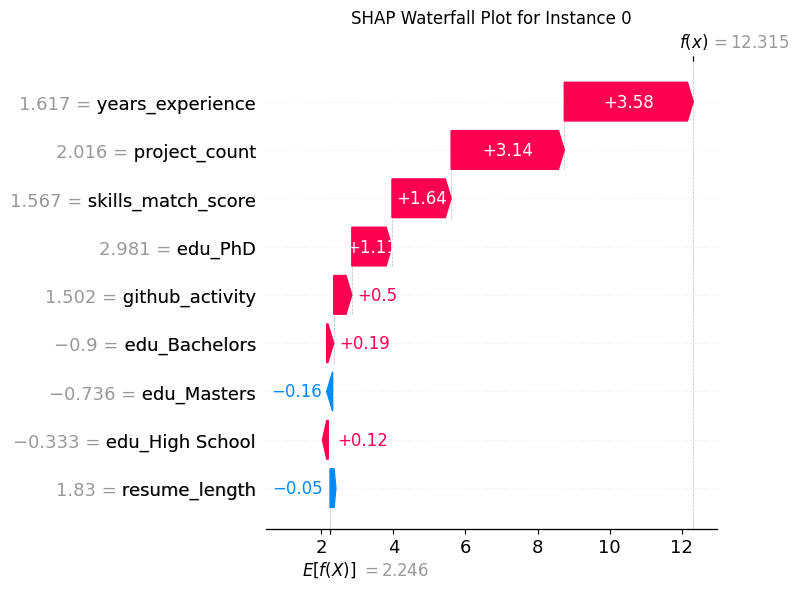

SHAP waterfall plot for instance 0 displayed above.


In [81]:
# Initialize SHAP JavaScript for rendering (if not already done implicitly by summary_plot)
shap.initjs()

# Select an instance to explain (e.g., the first test instance)
idx_to_explain = 0

# Create a SHAP Explanation object for the specific instance
explainer_linear = shap.LinearExplainer(model, X_train_scaled)
shap_values_single_instance = explainer_linear.shap_values(X_test_scaled[idx_to_explain])

# Create a SHAP Explanation object using the raw values for the waterfall plot
# This is crucial for the waterfall plot to work correctly
explanation = shap.Explanation(
    values=shap_values_single_instance,
    base_values=explainer_linear.expected_value,
    data=X_test_scaled[idx_to_explain],
    feature_names=X.columns.tolist()
)

# Generate the waterfall plot
fig_waterfall = plt.figure(figsize=(10, 6))
shap.plots.waterfall(explanation, show=False)
plt.title(f'SHAP Waterfall Plot for Instance {idx_to_explain}')
plt.tight_layout()
buf = io.BytesIO() # Create an in-memory buffer
plt.savefig(buf, format='png', bbox_inches='tight') # Save the figure to the buffer
buf.seek(0) # Rewind the buffer to the beginning
display(Image(buf.read())) # Display the image from the buffer
plt.close(fig_waterfall) # Close the specific figure after saving and displaying

print(f"SHAP waterfall plot for instance {idx_to_explain} displayed above.")

### SHAP vs. LIME Feature Importance Comparison


Comparison of SHAP and LIME Feature Importances for Instance {idx_to_explain}:
           Feature      SHAP     LIME
  years_experience  3.575538 0.306716
     project_count  3.136937 0.246439
skills_match_score  1.640708 0.167049
           edu_PhD  1.112626 0.077784
   github_activity  0.502161 0.057459
   edu_High School  0.121082 0.134556
     edu_Bachelors  0.194023 0.000000
       edu_Masters -0.164664 0.000000
     resume_length -0.049108 0.000000


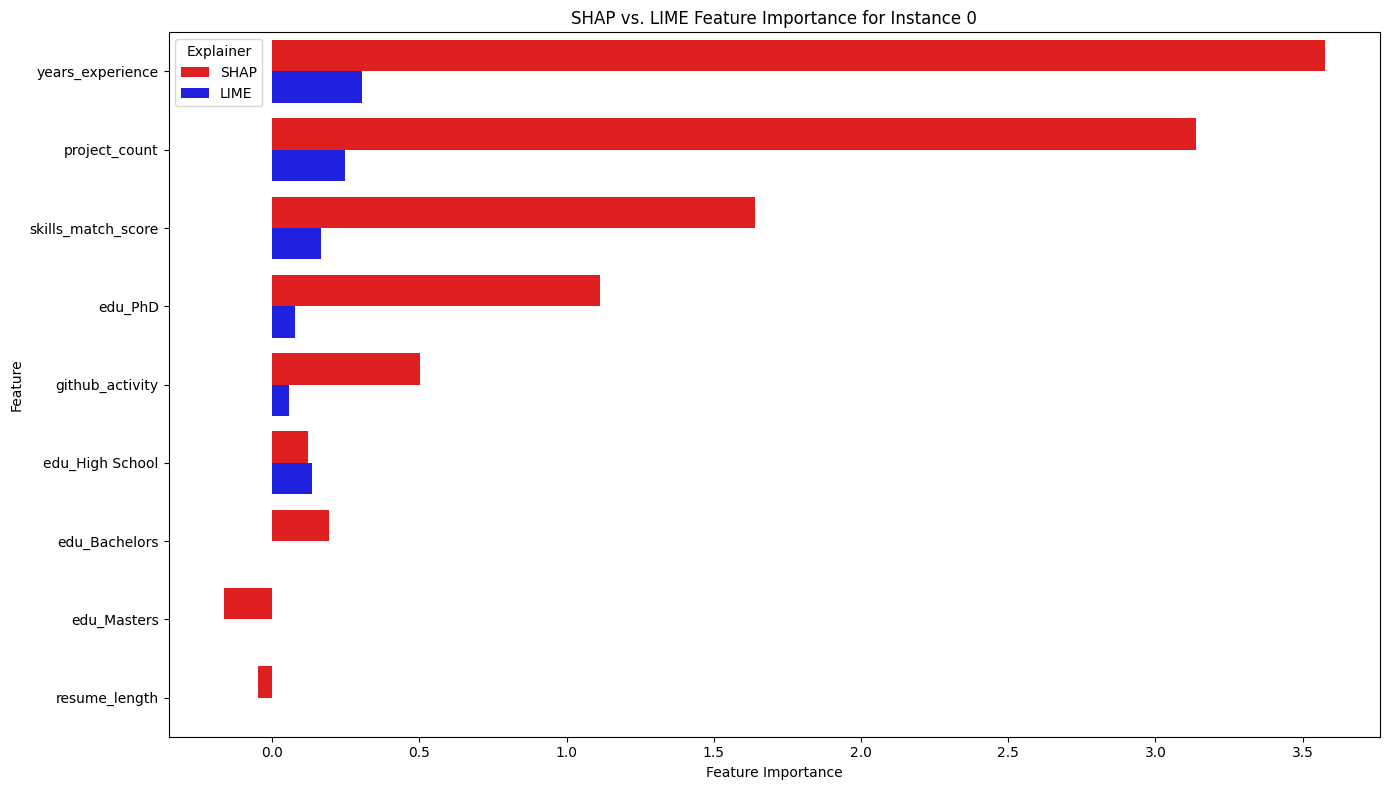

In [82]:
# Prepare data for comparison
# For LIME, extract feature names and weights from the explainer object for the chosen instance (idx)
lime_data = []
for feature, weight in exp.as_list():
    # LIME features often contain '> value' or '< value', clean them for comparison
    cleaned_feature = feature.split(' >')[0].split(' <')[0].split(' =')[0]
    lime_data.append({'Feature': cleaned_feature, 'LIME': weight})
lime_df = pd.DataFrame(lime_data)

# For SHAP, use the shap_values_single_instance from the waterfall plot
shap_data = []
for i, feature_name in enumerate(X.columns.tolist()):
    shap_data.append({'Feature': feature_name, 'SHAP': shap_values_single_instance[i]})
shap_df = pd.DataFrame(shap_data)

# Merge the two dataframes on 'Feature'
comparison_df = pd.merge(shap_df, lime_df, on='Feature', how='outer').fillna(0)

# Sort by total absolute importance for better visualization
comparison_df['Total_Importance'] = comparison_df['SHAP'].abs() + comparison_df['LIME'].abs()
comparison_df = comparison_df.sort_values(by='Total_Importance', ascending=False).drop(columns='Total_Importance')

# Display the comparison table
print("\nComparison of SHAP and LIME Feature Importances for Instance {idx_to_explain}:")
print(comparison_df.to_string(index=False))

# Visualize the comparison
fig_comparison = plt.figure(figsize=(14, 8))
df_melted = comparison_df.melt(id_vars='Feature', var_name='Explainer', value_name='Importance')
sns.barplot(x='Importance', y='Feature', hue='Explainer', data=df_melted, palette={'SHAP': 'red', 'LIME': 'blue'})
plt.title(f'SHAP vs. LIME Feature Importance for Instance {idx_to_explain}')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.tight_layout()
buf = io.BytesIO() # Create an in-memory buffer
plt.savefig(buf, format='png', bbox_inches='tight') # Save the figure to the buffer
buf.seek(0) # Rewind the buffer to the beginning
display(Image(buf.read())) # Display the image from the buffer
plt.close(fig_comparison) # Close the specific figure after saving and displaying

### Visualizing Fairness Metrics from MetricFrame

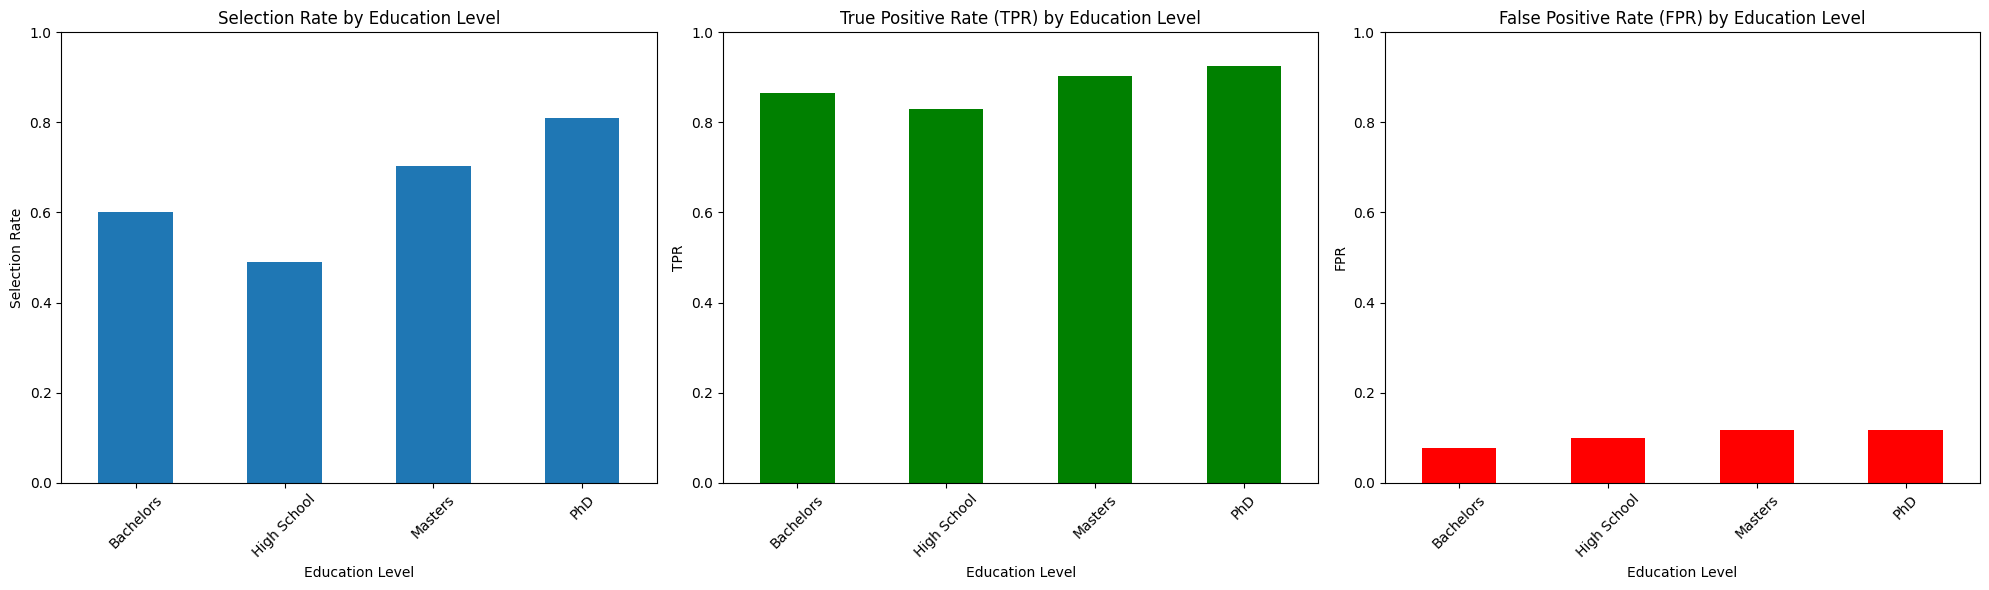

In [83]:
fig, ax = plt.subplots(1, 3, figsize=(20, 6))

# Plotting Selection Rate
metric_frame.by_group['selection_rate'].plot.bar(ax=ax[0], title='Selection Rate by Education Level',
                                                  ylabel='Selection Rate', xlabel='Education Level')
ax[0].set_ylim(0, 1)
ax[0].tick_params(axis='x', rotation=45)

# Plotting True Positive Rate (TPR)
metric_frame.by_group['tpr'].plot.bar(ax=ax[1], title='True Positive Rate (TPR) by Education Level',
                                      ylabel='TPR', xlabel='Education Level', color='green')
ax[1].set_ylim(0, 1)
ax[1].tick_params(axis='x', rotation=45)

# Plotting False Positive Rate (FPR)
metric_frame.by_group['fpr'].plot.bar(ax=ax[2], title='False Positive Rate (FPR) by Education Level',
                                      ylabel='FPR', xlabel='Education Level', color='red')
ax[2].set_ylim(0, 1)
ax[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Disparity in Selection Rates

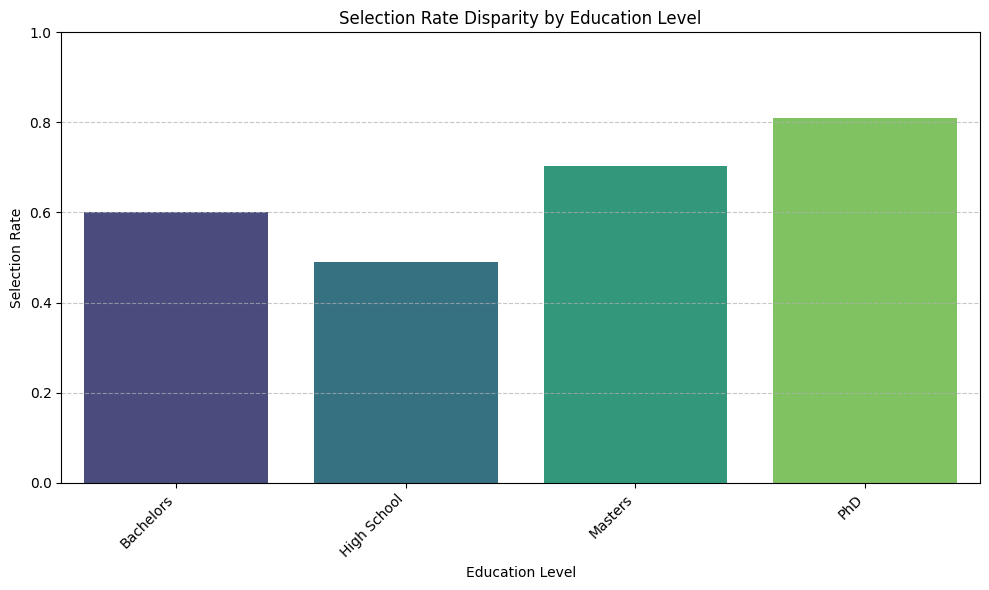

Interpretation: This plot clearly shows the differences in how frequently candidates from each education level are 'shortlisted' by the model. A higher bar indicates a higher selection rate for that group, highlighting potential disparities.


In [84]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(x=metric_frame.by_group.index, y=metric_frame.by_group['selection_rate'], hue=metric_frame.by_group.index, palette='viridis', legend=False)
plt.title('Selection Rate Disparity by Education Level')
plt.xlabel('Education Level')
plt.ylabel('Selection Rate')
plt.ylim(0, 1)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Interpretation: This plot clearly shows the differences in how frequently candidates from each education level are 'shortlisted' by the model. A higher bar indicates a higher selection rate for that group, highlighting potential disparities.")

### True Positive Rate (TPR) Disparity

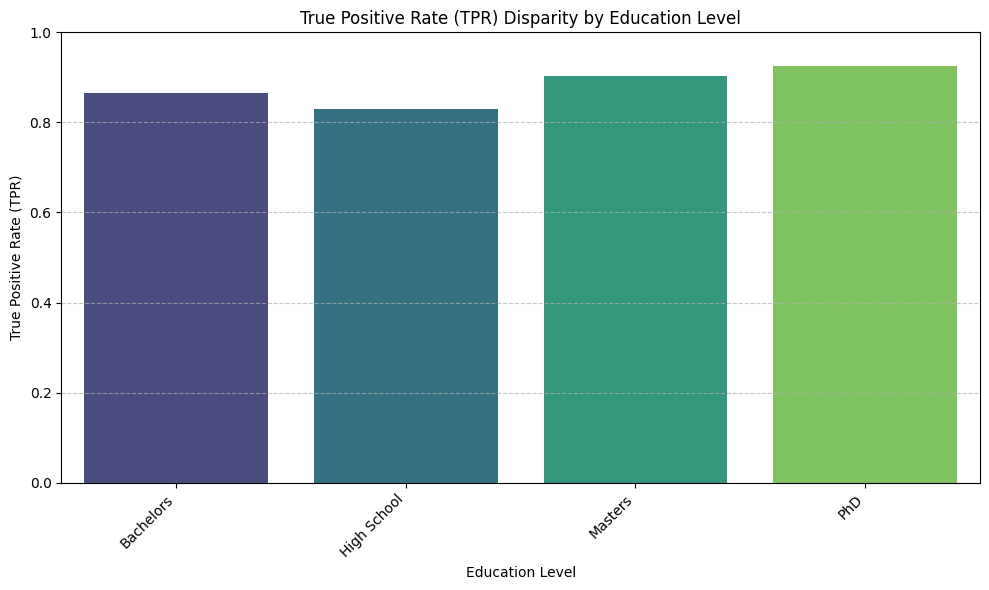

Interpretation: This plot shows how effectively the model identifies 'shortlisted' candidates within each education level. A higher bar indicates a higher TPR for that group.


In [85]:
plt.figure(figsize=(10, 6))
sns.barplot(x=metric_frame.by_group.index, y=metric_frame.by_group['tpr'], hue=metric_frame.by_group.index, palette='viridis', legend=False)
plt.title('True Positive Rate (TPR) Disparity by Education Level')
plt.xlabel('Education Level')
plt.ylabel('True Positive Rate (TPR)')
plt.ylim(0, 1)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Interpretation: This plot shows how effectively the model identifies 'shortlisted' candidates within each education level. A higher bar indicates a higher TPR for that group.")